<a href="https://colab.research.google.com/github/JayadharsiniMathiyalagan/Fundamentals-of-Machine-Learning/blob/main/FOML_EXP_9(a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Confusion Matrix:
 [[10  0  0]
 [ 0  7  2]
 [ 0  3  8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.70      0.78      0.74         9
           2       0.80      0.73      0.76        11

    accuracy                           0.83        30
   macro avg       0.83      0.84      0.83        30
weighted avg       0.84      0.83      0.83        30



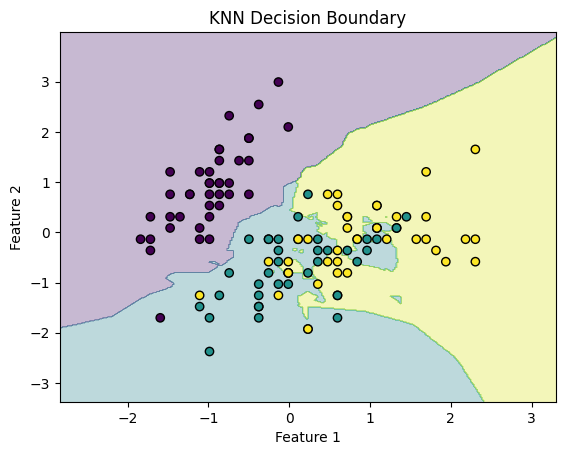

In [12]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import load_iris

# ==============================
# STEP 2: Load Dataset
# ==============================
data = load_iris()

# Use only 2 features for plotting
X = data.data[:, :2]
y = data.target

# ==============================
# STEP 3: Split Data
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# STEP 4: Feature Scaling
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# STEP 5: Train Model
# ==============================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# ==============================
# STEP 6: Predictions
# ==============================
y_pred = knn.predict(X_test)

# ==============================
# STEP 7: Evaluation
# ==============================
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# STEP 8: Visualization (IMPORTANT)
# ==============================
# Create mesh grid
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict on grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k')

plt.title("KNN Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()